In [ ]:
!pip install drain3

import os
import pandas as pd
import re
import time
from drain3 import TemplateMiner
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

drive.mount('/content/drive', force_remount=True)
print(os.listdir('/content/drive/MyDrive'))

log_file_path = "/content/drive/MyDrive/HDFS.log"
print("Setup complete - ready to parse!")

  Preparing metadata (setup.py) ... done
  Created wheel for drain3: filename=drain3-0.9.11-py3-none-any.whl size=23998 sha256=426fa147e9bbbc9f7707271cebedf7833a758f0082144b3bd024105365464e89
  Stored in directory: /root/.cache/pip/wheels/77/7b/c6/81836300840d5e110d022e5efa4337472f48b97faa46540388
Successfully built drain3
  Attempting uninstall: jsonpickle
    Found existing installation: jsonpickle 4.1.2
    Uninstalling jsonpickle-4.1.2:
      Successfully uninstalled jsonpickle-4.1.2
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyiceberg 0.11.1 requires cachetools<7.0,>=5.5, but you have cachetools 4.2.1 which is incompatible.
Mounted at /content/drive
['Programme%20Hanbook%20MDS.pdf', 'Pr

In [ ]:
template_miner = TemplateMiner()
parsed_results = []

sample_size = 500000

with open(log_file_path, "r", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= sample_size:
            break
        line = line.strip()
        if not line:
            continue
        result = template_miner.add_log_message(line)
        parsed_results.append({
            "raw_log": line,
            "template": result["template_mined"],
            "cluster_id": result["cluster_id"]
        })

df = pd.DataFrame(parsed_results)
df.to_csv("/content/drive/MyDrive/HDFS_structured_sample.csv", index=False)
print(f"Done! Parsed {len(df)} log lines into {df['cluster_id'].nunique()} unique templates.")

Done! Parsed 500000 log lines into 35 unique templates.


In [ ]:
sample_size = 500000

parsed_results = []

with open(log_file_path, "r", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= sample_size:
            break
        line = line.strip()
        if not line:
            continue
        result = template_miner.add_log_message(line)
        parsed_results.append({
            "raw_log": line,
            "template": result["template_mined"],
            "cluster_id": result["cluster_id"]
        })

df = pd.DataFrame(parsed_results)
df.to_csv("/content/drive/MyDrive/HDFS_structured_sample.csv", index=False)

print(f"Done! Parsed {len(df)} log lines into {df['cluster_id'].nunique()} unique templates.")

Done! Parsed 500000 log lines into 34 unique templates.


In [ ]:
labels_df = pd.read_csv("/content/drive/MyDrive/anomaly_label.csv")

def extract_block_id(log_line):
    match = re.search(r'(blk_-?\d+)', log_line)
    return match.group(1) if match else None

df['BlockId'] = df['raw_log'].apply(extract_block_id)

df_labeled = df.merge(labels_df, on='BlockId', how='left')
df_labeled = df_labeled.dropna(subset=['Label'])

df_labeled.to_csv("/content/drive/MyDrive/HDFS_structured_labeled.csv", index=False)
print(f"Saved labeled dataset! Remaining rows: {len(df_labeled)}")
print(df_labeled['Label'].value_counts())

Saved labeled dataset! Remaining rows: 500000
Label
Normal     480905
Anomaly     19095
Name: count, dtype: int64


In [ ]:
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df_labeled['template'])
y = df_labeled['Label'].apply(lambda x: 1 if x == 'Anomaly' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 400000, Test size: 100000


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": LinearSVC(max_iter=2000),
    "Naive Bayes": MultinomialNB()
}

results = []
for name, model in models.items():
    print(f"Training {name}...")
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Train Time (s)": train_time
    })
    print(f"{name} done in {train_time:.2f}s.")

results_df = pd.DataFrame(results)
results_df.to_csv("/content/drive/MyDrive/model_comparison_results.csv", index=False)
print(results_df)

Training Logistic Regression...
Logistic Regression done in 3.58s.
Training Random Forest...
Random Forest done in 50.87s.
Training SVM...
SVM done in 6.81s.
Training Naive Bayes...
Naive Bayes done in 0.06s.
                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression   0.96432   0.943463  0.069914  0.130180   
1        Random Forest   0.96432   0.943463  0.069914  0.130180   
2                  SVM   0.96432   0.943463  0.069914  0.130180   
3          Naive Bayes   0.96405   0.959016  0.061273  0.115186   

   Train Time (s)  
0        3.579910  
1       50.865408  
2        6.806896  
3        0.056348  


In [ ]:
models_balanced = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM": LinearSVC(class_weight='balanced', max_iter=2000),
    "Naive Bayes": MultinomialNB()
}

results_balanced = []
for name, model in models_balanced.items():
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train
    y_pred = model.predict(X_test)
    results_balanced.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Train Time (s)": train_time
    })

results_balanced_df = pd.DataFrame(results_balanced)
results_balanced_df.to_csv("/content/drive/MyDrive/model_comparison_results_balanced.csv", index=False)
print(results_balanced_df)

                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression   0.67394   0.054036  0.456664  0.096637   
1        Random Forest   0.67394   0.054036  0.456664  0.096637   
2                  SVM   0.67394   0.054036  0.456664  0.096637   
3          Naive Bayes   0.96405   0.959016  0.061273  0.115186   

   Train Time (s)  
0        1.681882  
1       44.930129  
2      111.675543  
3        0.085976  


In [ ]:
final_comparison = results_df.merge(results_balanced_df, on="Model", suffixes=("_before", "_after"))
final_comparison = final_comparison[[
    "Model", "Accuracy_before", "Accuracy_after",
    "Precision_before", "Precision_after",
    "Recall_before", "Recall_after",
    "F1-score_before", "F1-score_after"
]]
final_comparison.to_csv("/content/drive/MyDrive/final_model_comparison.csv", index=False)
print(final_comparison)

                 Model  Accuracy_before  Accuracy_after  Precision_before  \
0  Logistic Regression          0.96432         0.67394          0.943463   
1        Random Forest          0.96432         0.67394          0.943463   
2                  SVM          0.96432         0.67394          0.943463   
3          Naive Bayes          0.96405         0.96405          0.959016   

   Precision_after  Recall_before  Recall_after  F1-score_before  \
0         0.054036       0.069914      0.456664         0.130180   
1         0.054036       0.069914      0.456664         0.130180   
2         0.054036       0.069914      0.456664         0.130180   
3         0.959016       0.061273      0.061273         0.115186   

   F1-score_after  
0        0.096637  
1        0.096637  
2        0.096637  
3        0.115186  


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Programme%20Hanbook%20MDS.pdf', 'Programme%20Hanbook%20MDS.gdoc', 'HDFS.log', 'anomaly_label.csv', 'Colab Notebooks', 'HDFS_structured_labeled.csv', 'HDFS_structured_sample.csv', 'model_comparison_results.csv', 'model_comparison_results_balanced.csv', 'final_model_comparison.csv', 'HDFS_representative_sample.csv', 'model_comparison_results_representative.csv', 'model_comparison_results_representative_balanced.csv', 'final_model_comparison_representative.csv', 'confusion_matrices.png', 'precision_recall_comparison.png']


In [ ]:
labels_df = pd.read_csv("/content/drive/MyDrive/anomaly_label.csv")
print(labels_df['Label'].value_counts(normalize=True))

Label
Normal     0.97072
Anomaly    0.02928
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

target_blocks = 50000  # adjust based on how much you can process comfortably

sampled_blocks, _ = train_test_split(
    labels_df,
    train_size=target_blocks,
    stratify=labels_df['Label'],
    random_state=42
)

print(sampled_blocks['Label'].value_counts(normalize=True))  # should closely match Step 1
selected_block_ids = set(sampled_blocks['BlockId'])

Label
Normal     0.97072
Anomaly    0.02928
Name: proportion, dtype: float64


In [ ]:
import re

def extract_block_id(log_line):
    match = re.search(r'(blk_-?\d+)', log_line)
    return match.group(1) if match else None

template_miner = TemplateMiner()
parsed_results = []

with open(log_file_path, "r", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        block_id = extract_block_id(line)
        if block_id not in selected_block_ids:
            continue
        result = template_miner.add_log_message(line)
        parsed_results.append({
            "raw_log": line,
            "template": result["template_mined"],
            "BlockId": block_id
        })

df_representative = pd.DataFrame(parsed_results)
print(f"Collected {len(df_representative)} log lines from {df_representative['BlockId'].nunique()} blocks")

Collected 970509 log lines from 50000 blocks


In [ ]:
df_representative_labeled = df_representative.merge(labels_df, on='BlockId', how='left')
df_representative_labeled.to_csv("/content/drive/MyDrive/HDFS_representative_sample.csv", index=False)

print(df_representative_labeled['Label'].value_counts(normalize=True))
print("Saved representative sample!")

Label
Normal     0.974809
Anomaly    0.025191
Name: proportion, dtype: float64
Saved representative sample!


In [ ]:
vectorizer_rep = TfidfVectorizer(max_features=1000)
X_rep = vectorizer_rep.fit_transform(df_representative_labeled['template'])
y_rep = df_representative_labeled['Label'].apply(lambda x: 1 if x == 'Anomaly' else 0)

X_train_rep, X_test_rep, y_train_rep, y_test_rep = train_test_split(
    X_rep, y_rep, test_size=0.2, random_state=42, stratify=y_rep
)
print(f"Train size: {X_train_rep.shape[0]}, Test size: {X_test_rep.shape[0]}")

Train size: 776407, Test size: 194102


In [ ]:
results_rep = []
for name, model in models.items():
    print(f"Training {name} on representative sample...")
    start_train = time.time()
    model.fit(X_train_rep, y_train_rep)
    train_time = time.time() - start_train
    y_pred = model.predict(X_test_rep)
    results_rep.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_rep, y_pred),
        "Precision": precision_score(y_test_rep, y_pred, zero_division=0),
        "Recall": recall_score(y_test_rep, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_rep, y_pred, zero_division=0),
        "Train Time (s)": train_time
    })

results_rep_df = pd.DataFrame(results_rep)
results_rep_df.to_csv("/content/drive/MyDrive/model_comparison_results_representative.csv", index=False)
print(results_rep_df)

Training Logistic Regression on representative sample...
Training Random Forest on representative sample...
Training SVM on representative sample...
Training Naive Bayes on representative sample...
                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression  0.976378   0.717546  0.102863  0.179932   
1        Random Forest  0.976528   0.759317  0.100000  0.176726   
2                  SVM  0.976512   0.758998  0.099182  0.175439   
3          Naive Bayes  0.976244   0.736842  0.088753  0.158423   

   Train Time (s)  
0        2.085889  
1      153.201911  
2       18.601943  
3        0.113920  


In [ ]:

results_rep_balanced = []
for name, model in models_balanced.items():
    print(f"Training {name} (balanced) on representative sample...")
    start_train = time.time()
    model.fit(X_train_rep, y_train_rep)
    train_time = time.time() - start_train
    y_pred = model.predict(X_test_rep)
    results_rep_balanced.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_rep, y_pred),
        "Precision": precision_score(y_test_rep, y_pred, zero_division=0),
        "Recall": recall_score(y_test_rep, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_rep, y_pred, zero_division=0),
        "Train Time (s)": train_time
    })

results_rep_balanced_df = pd.DataFrame(results_rep_balanced)
results_rep_balanced_df.to_csv("/content/drive/MyDrive/model_comparison_results_representative_balanced.csv", index=False)
print(results_rep_balanced_df)

Training Logistic Regression (balanced) on representative sample...
Training Random Forest (balanced) on representative sample...
Training SVM (balanced) on representative sample...
Training Naive Bayes (balanced) on representative sample...
                 Model  Accuracy  Precision    Recall  F1-score  \
0  Logistic Regression  0.738849   0.036587  0.369734  0.066586   
1        Random Forest  0.753032   0.036960  0.351329  0.066883   
2                  SVM  0.738921   0.036598  0.369734  0.066603   
3          Naive Bayes  0.976244   0.736842  0.088753  0.158423   

   Train Time (s)  
0        5.043617  
1      141.746785  
2      471.254086  
3        0.117099  


In [ ]:
final_comparison_rep = results_rep_df.merge(results_rep_balanced_df, on="Model", suffixes=("_before", "_after"))
final_comparison_rep = final_comparison_rep[[
    "Model", "Accuracy_before", "Accuracy_after",
    "Precision_before", "Precision_after",
    "Recall_before", "Recall_after",
    "F1-score_before", "F1-score_after"
]]
final_comparison_rep.to_csv("/content/drive/MyDrive/final_model_comparison_representative.csv", index=False)
print(final_comparison_rep)

                 Model  Accuracy_before  Accuracy_after  Precision_before  \
0  Logistic Regression         0.976378        0.738849          0.717546   
1        Random Forest         0.976528        0.753032          0.759317   
2                  SVM         0.976512        0.738921          0.758998   
3          Naive Bayes         0.976244        0.976244          0.736842   

   Precision_after  Recall_before  Recall_after  F1-score_before  \
0         0.036587       0.102863      0.369734         0.179932   
1         0.036960       0.100000      0.351329         0.176726   
2         0.036598       0.099182      0.369734         0.175439   
3         0.736842       0.088753      0.088753         0.158423   

   F1-score_after  
0        0.066586  
1        0.066883  
2        0.066603  
3        0.158423  


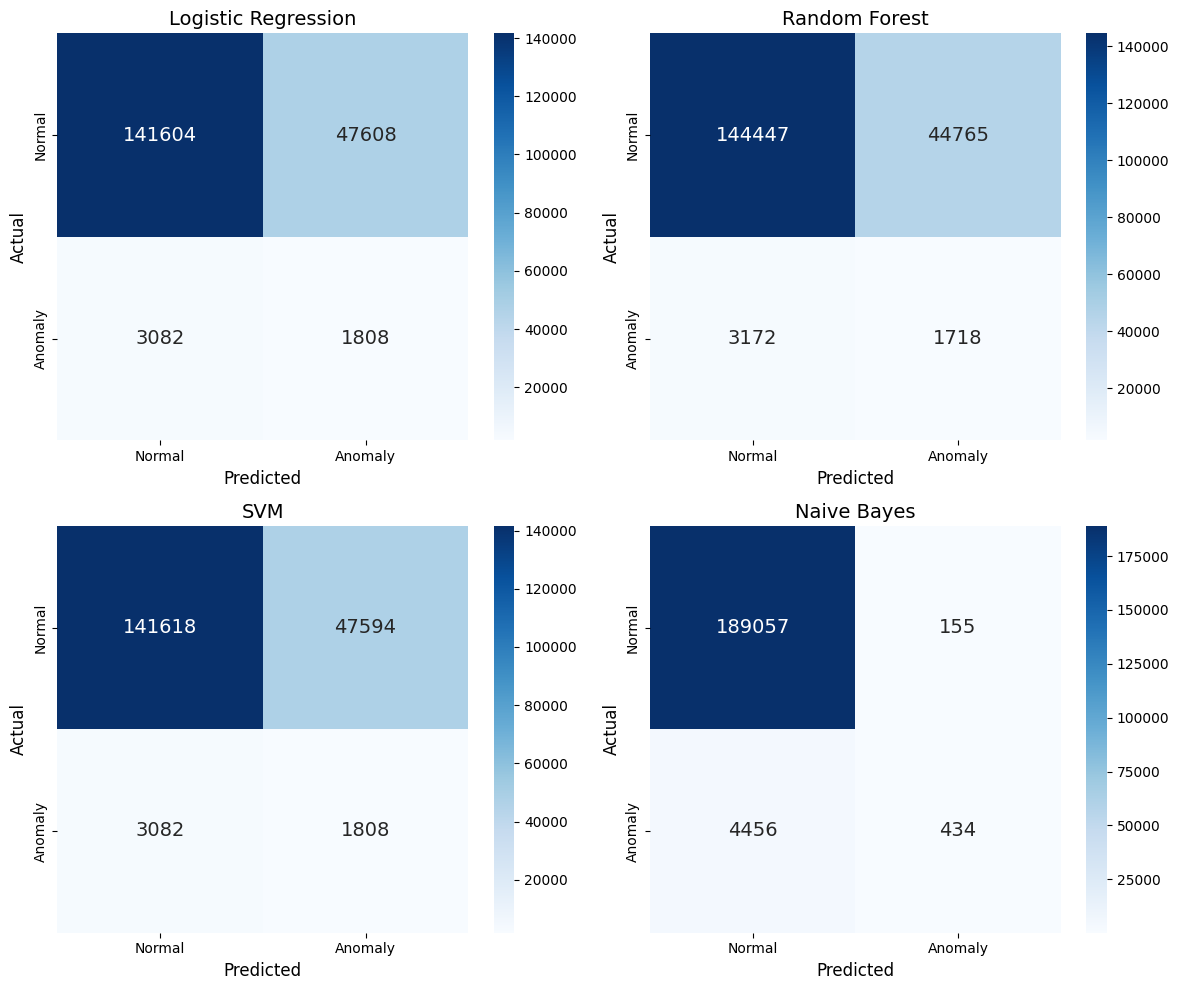

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models_balanced.items()):
    y_pred = model.predict(X_test_rep)
    cm = confusion_matrix(y_test_rep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
                annot_kws={"size": 14})
    ax.set_title(name, fontsize=14)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('/content/drive/MyDrive/confusion_matrices.png')

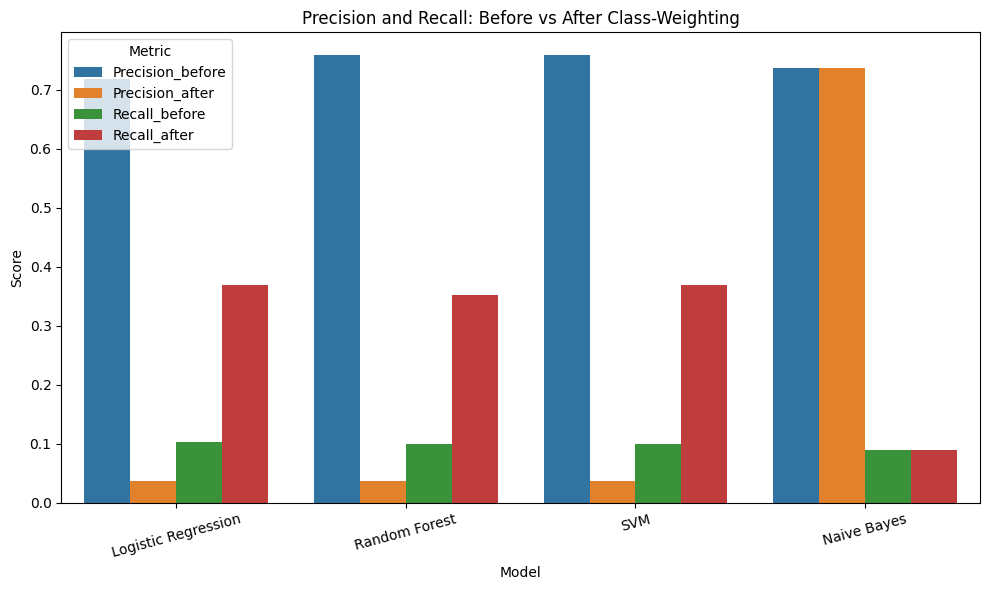

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = final_comparison_rep.melt(id_vars='Model',
    value_vars=['Precision_before', 'Precision_after', 'Recall_before', 'Recall_after'],
    var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric')
plt.title('Precision and Recall: Before vs After Class-Weighting')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/precision_recall_comparison.png', dpi=150)
plt.show()

In [21]:
from google.colab import files
files.download('/content/drive/MyDrive/confusion_matrices.png')
files.download('/content/drive/MyDrive/precision_recall_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>